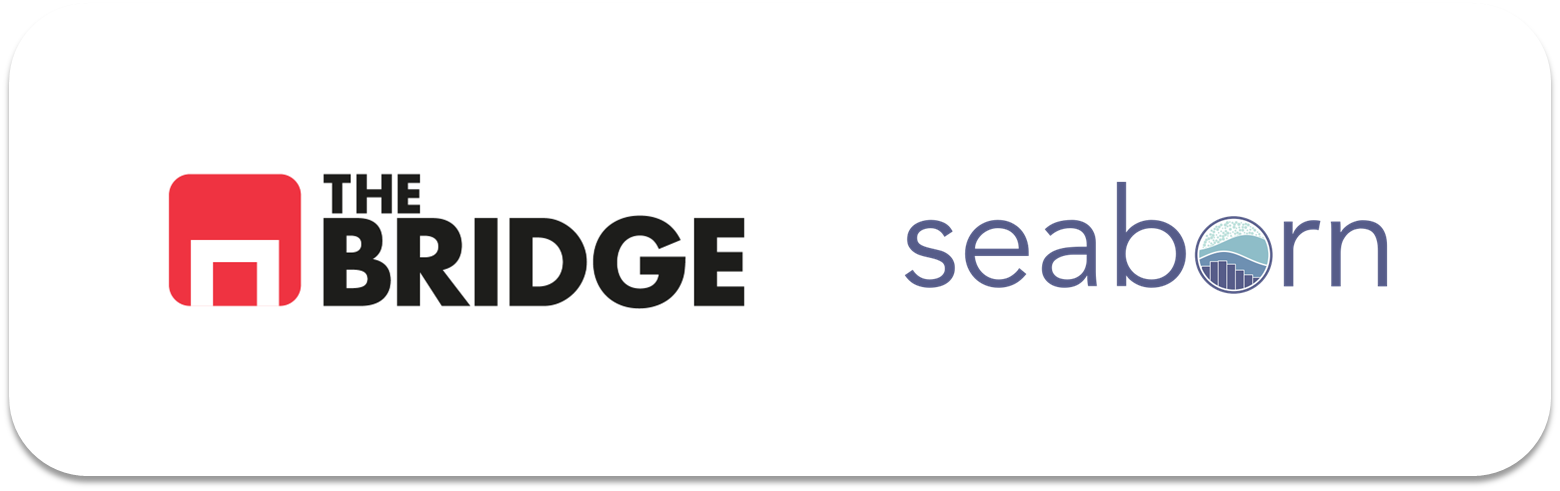

## PRACTICA OBLIGATORIA: **Visualización y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.mode.copy_on_write = True

C:\Users\User\AppData\Local\Temp\ipykernel_28308\2026339008.py:6: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


## #1 VISUALIZACION

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [232]:
df = pd.read_csv ('./data/california_cities.csv')

In [233]:
df.head()

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [234]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    str    
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), str(1)
memory usage: 52.8 KB


In [235]:
df['elevation_m'] = df['elevation_m'].fillna(df['elevation_ft'] * 0.3048)

In [236]:

df['elevation_ft'] = df['elevation_ft'].fillna(df['elevation_m'] / 0.3048)

In [237]:
# km2 ↔ sq_mi (1 sq_mi = 2.58999 km2)
df['area_total_km2'] = df['area_total_km2'].fillna(df['area_total_sq_mi'] * 2.58999)
df['area_total_sq_mi'] = df['area_total_sq_mi'].fillna(df['area_total_km2'] / 2.58999)

In [238]:
df['area_water_km2'] = df['area_water_km2'].fillna(df['area_water_sq_mi'] * 2.58999)
df['area_water_sq_mi'] = df['area_water_sq_mi'].fillna(df['area_water_km2'] / 2.58999)

In [239]:
df['area_land_km2'] = df['area_land_km2'].fillna(df['area_land_sq_mi'] * 2.58999)
df['area_land_sq_mi'] = df['area_land_sq_mi'].fillna(df['area_land_km2'] / 2.58999)

In [240]:
df['area_water_percent'] = df['area_water_percent'].fillna(
    (df['area_water_km2'] / df['area_total_km2']) * 100
)

In [241]:
df.isna().sum().sort_values(ascending=False)

elevation_m           8
elevation_ft          8
area_total_km2        1
area_total_sq_mi      1
city                  0
Unnamed: 0            0
latd                  0
longd                 0
area_land_sq_mi       0
population_total      0
area_water_sq_mi      0
area_land_km2         0
area_water_km2        0
area_water_percent    0
dtype: int64

In [242]:
df.dropna(inplace=True)

In [243]:
# para eliminar el índice del csv como columna (info innecesaria)

df.drop(columns=['Unnamed: 0'], inplace=True)               

In [244]:
df

,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,Adelanto,34.576111,-117.432778,875.0000,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,AgouraHills,34.153333,-118.761667,281.0000,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,Alameda,37.756111,-122.274444,10.0584,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,Albany,37.886944,-122.297778,13.1064,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,Alhambra,34.081944,-118.135000,150.0000,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,Yountville,38.403056,-122.362222,30.0000,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00
478,Yreka,41.726667,-122.637500,787.0000,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72
479,YubaCity,39.134722,-121.626111,18.0000,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53
480,Yucaipa,34.030278,-117.048611,798.0000,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02


### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA OPCIONAL: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños.

In [245]:
def scatter_with_controls(df, x_col, y_col, color_col=None, size_col=50, scale=1, legend=True):

    fig, ax = plt.subplots(figsize=(20, 10))

    # sobre el tamaño

    if isinstance(size_col, str):
        sizes_values = df[size_col] * scale                         # Series con tamaños escalados
        size_range = (sizes_values.min(), sizes_values.max())
    else:
        sizes_values = size_col                                     # Número fijo
        size_range = None

    # Columna categórica + legend
    if color_col is not None and legend:
        max_cats = 15                                               # máx de categorías para no colapsar la leyenda
        mostrar_leyenda = df[color_col].nunique() <= max_cats

        sns.scatterplot(
            data=df,
            x=x_col, y=y_col,
            hue=color_col,
            size=size_col if isinstance(size_col, str) else None,
            sizes=size_range,
            palette="viridis",
            alpha=0.5,
            ax=ax,
            legend=mostrar_leyenda
        )
        if not isinstance(size_col, str):
            ax.collections[0].set_sizes([sizes_values])  # tamaño fijo

        if mostrar_leyenda:
            ax.legend(ncol=2, loc="upper right", frameon=False, labelspacing=2)

    # Columna categórica y COLORBAR
    elif color_col is not None and not legend:
        codes = df[color_col].astype("category").cat.codes
        s = sizes_values if isinstance(size_col, str) else sizes_values
        scatter = ax.scatter(
            df[x_col], df[y_col],
            c=codes,
            s=s,
            cmap="viridis",
            alpha=0.5
        )
        plt.colorbar(scatter, ax=ax, label=color_col)

        # Leyenda de tamaños (min / mediana / max)
        if isinstance(size_col, str):
            for val in [df[size_col].min(), df[size_col].median(), df[size_col].max()]:
                ax.scatter([], [], s=val * scale, label=f"{val:.0f}", color="gray", alpha=0.7)
            ax.legend(title=size_col, bbox_to_anchor=(1.15, 1), loc="upper left",
                      frameon=False, labelspacing=2)

    # Sin columna categórica
    else:
        sns.scatterplot(
            data=df,
            x=x_col, y=y_col,
            size=size_col if isinstance(size_col, str) else None,
            sizes=size_range,
            alpha=0.5,
            ax=ax
        )
        if not isinstance(size_col, str):
            ax.collections[0].set_sizes([sizes_values])

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")
    plt.tight_layout()

    return ax

<Axes: title={'center': 'longd vs latd'}, xlabel='longd', ylabel='latd'>

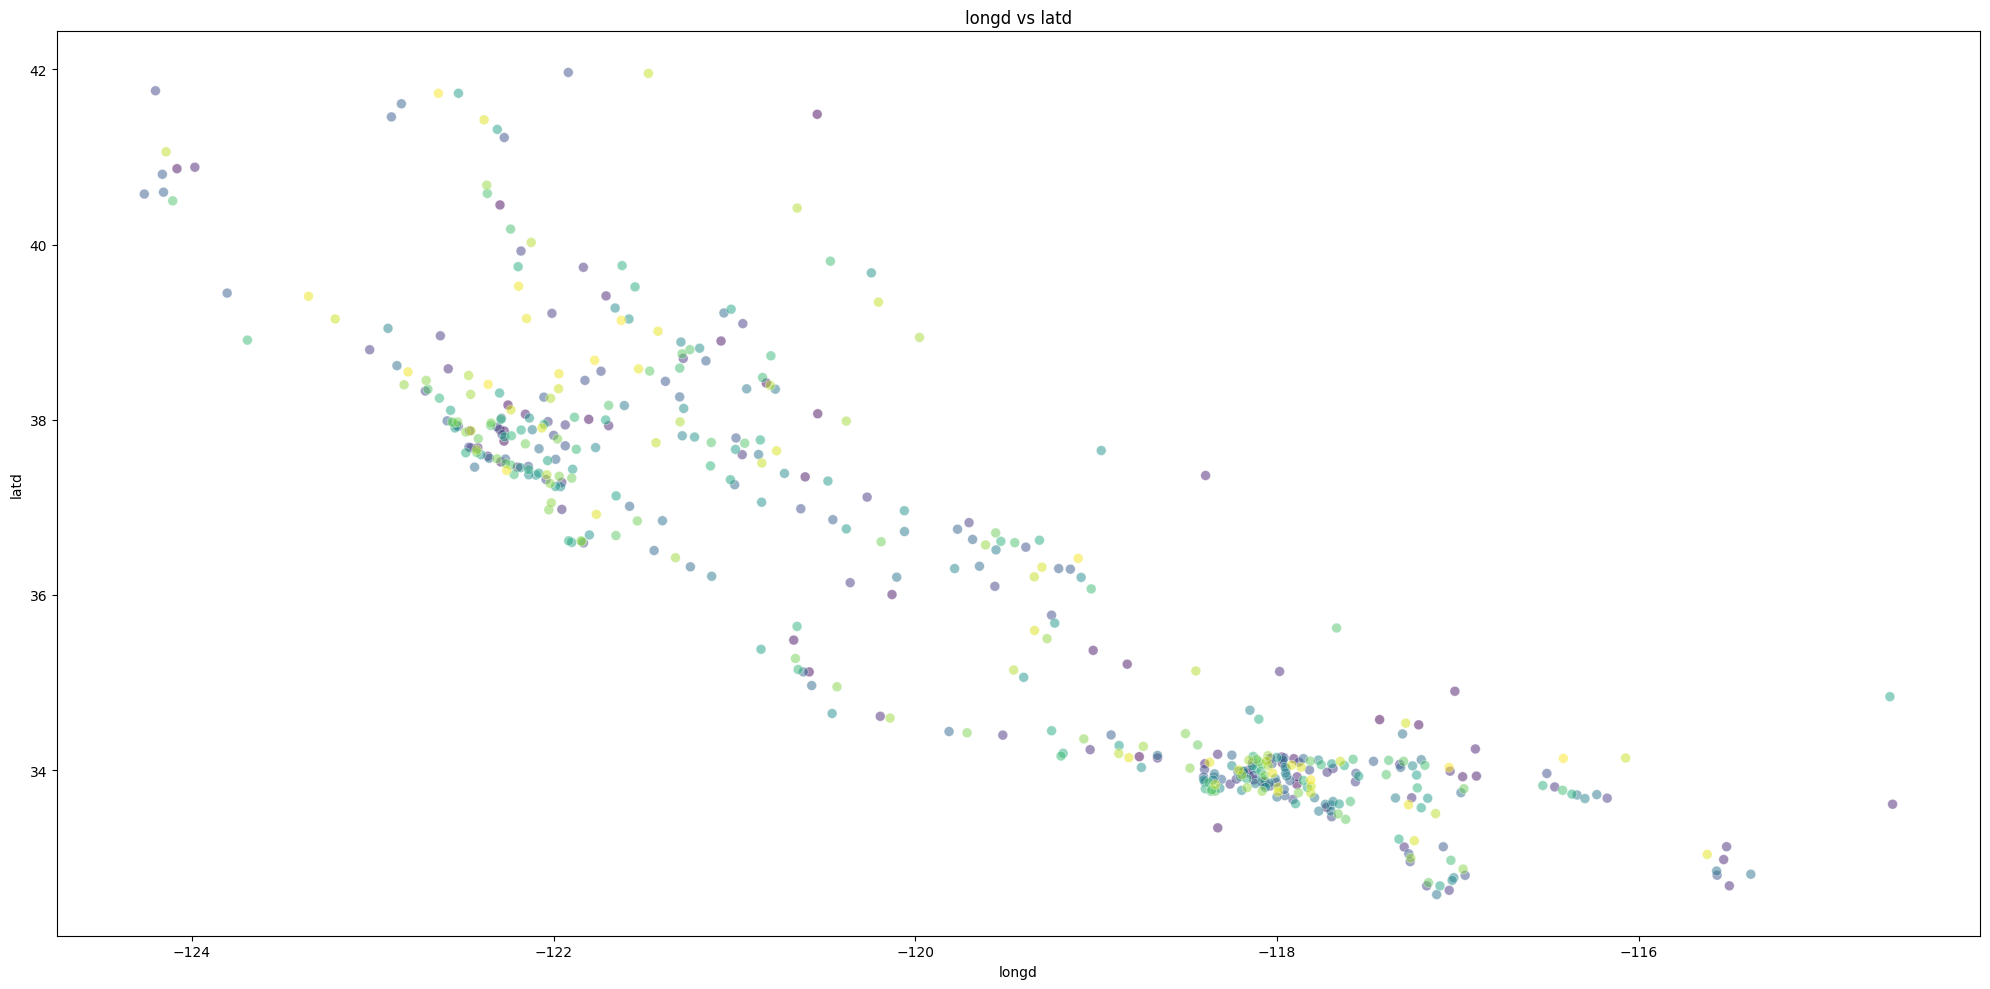

In [246]:
# Ejemplo de tammaño fijo, con categoría
scatter_with_controls(df, 'longd', 'latd', color_col='city', size_col=50)

<Axes: title={'center': 'longd vs latd'}, xlabel='longd', ylabel='latd'>

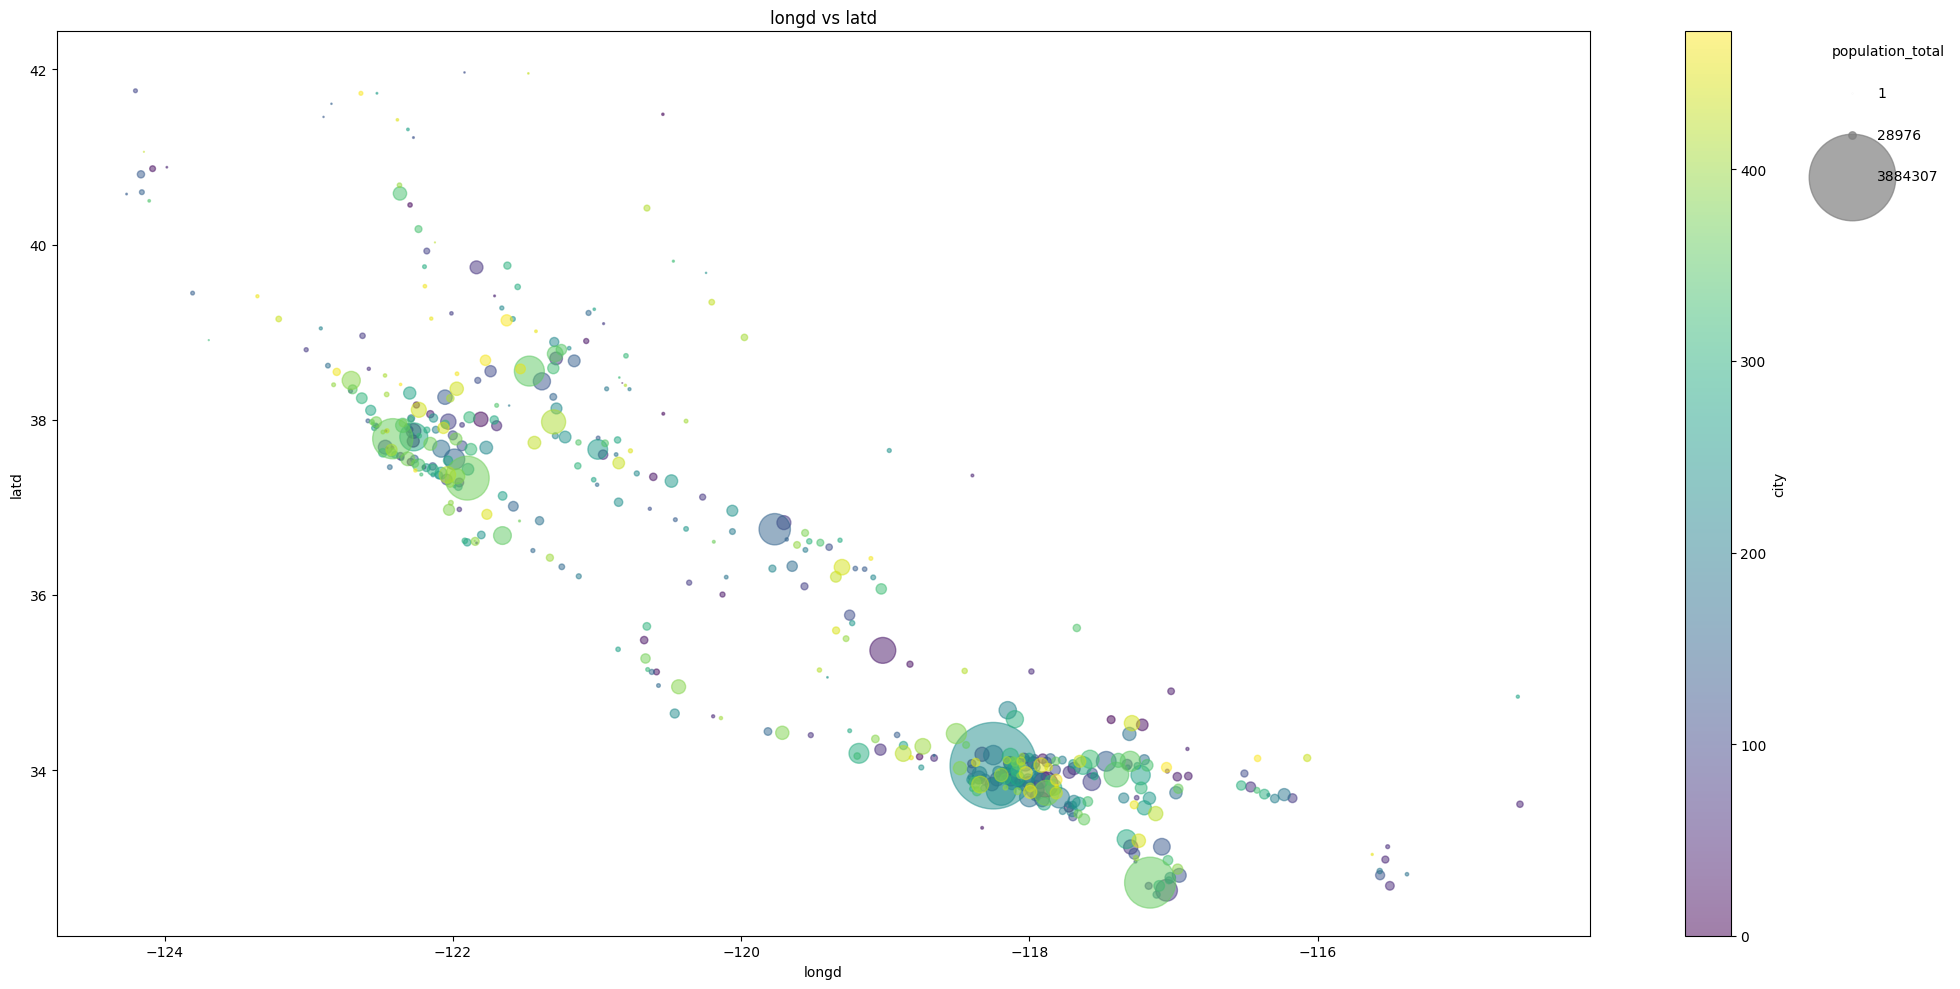

In [247]:
# Ejemplo con tamaño por columna (population_total escalado), con colorbar

scatter_with_controls(df, 'longd', 'latd', color_col='city', size_col='population_total', scale=1/1000, legend=False)

<Axes: title={'center': 'elevation_m vs population_total'}, xlabel='elevation_m', ylabel='population_total'>

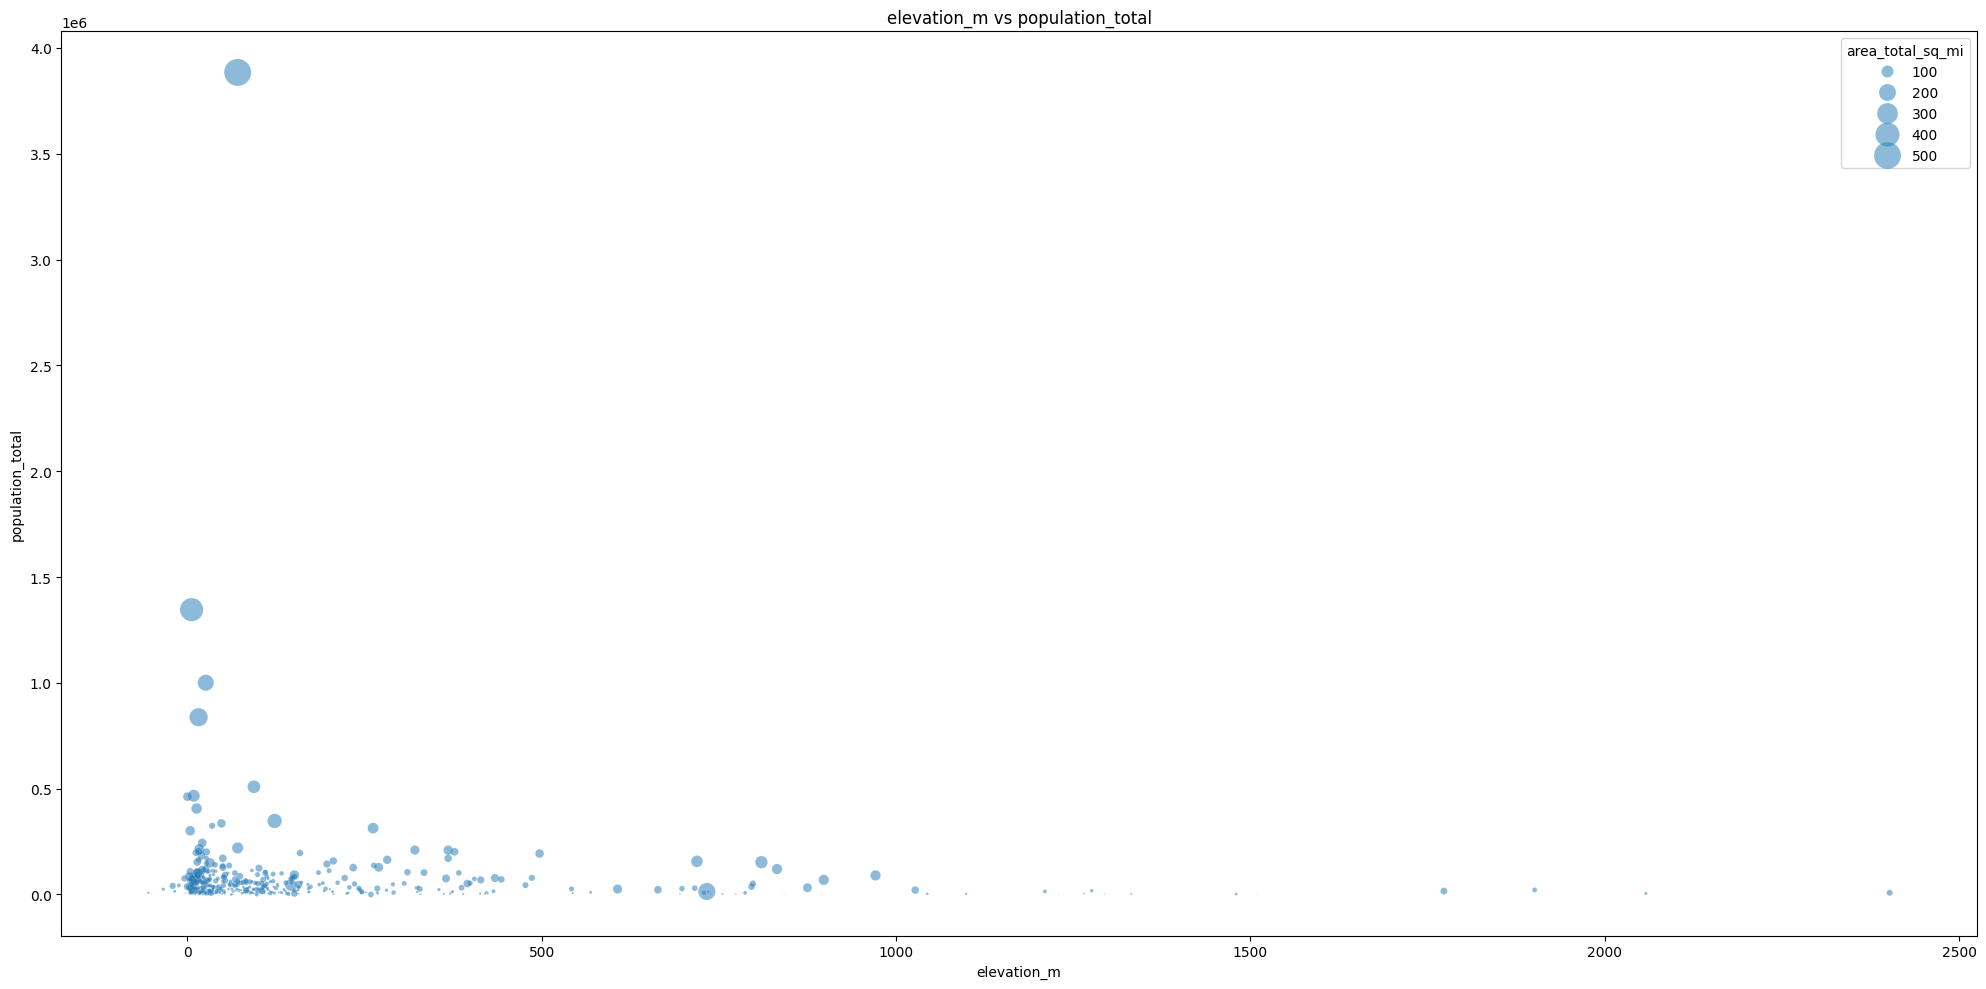

In [248]:
# Ejemplo sin categoría

scatter_with_controls(df, 'elevation_m', 'population_total', size_col='area_total_sq_mi', scale=0.75)

### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

Una vez calculado el logaritmo, también puedes probar a categorizar la población, aquí tienes un ejemplo de como podría salir para que lo tengas de referencia:

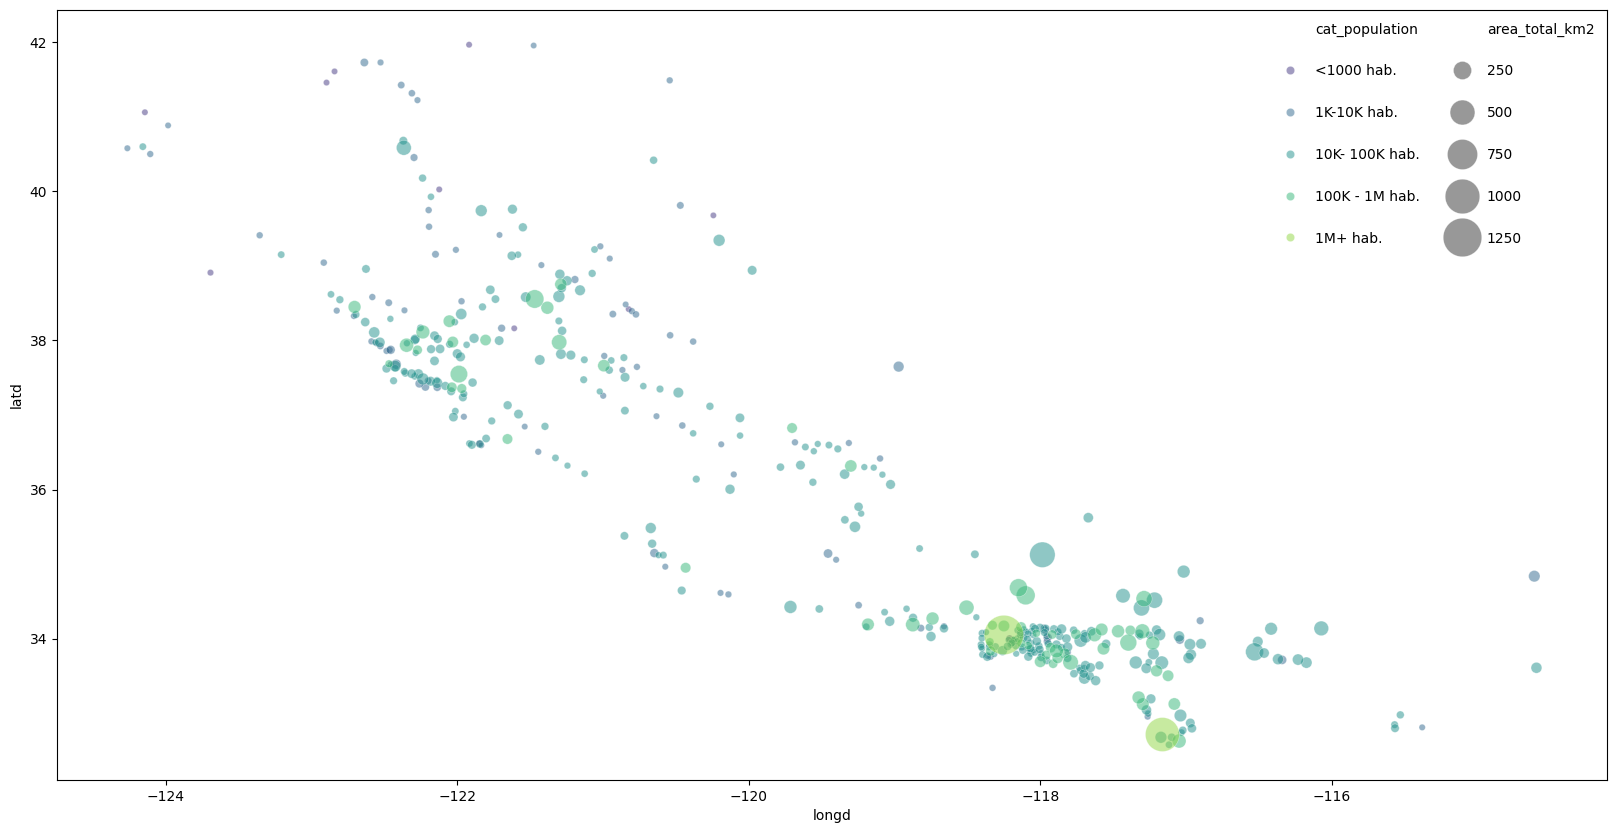

In [249]:
df['log_poblacion'] = np.log10(df['population_total'])

<Axes: title={'center': 'longd vs latd'}, xlabel='longd', ylabel='latd'>

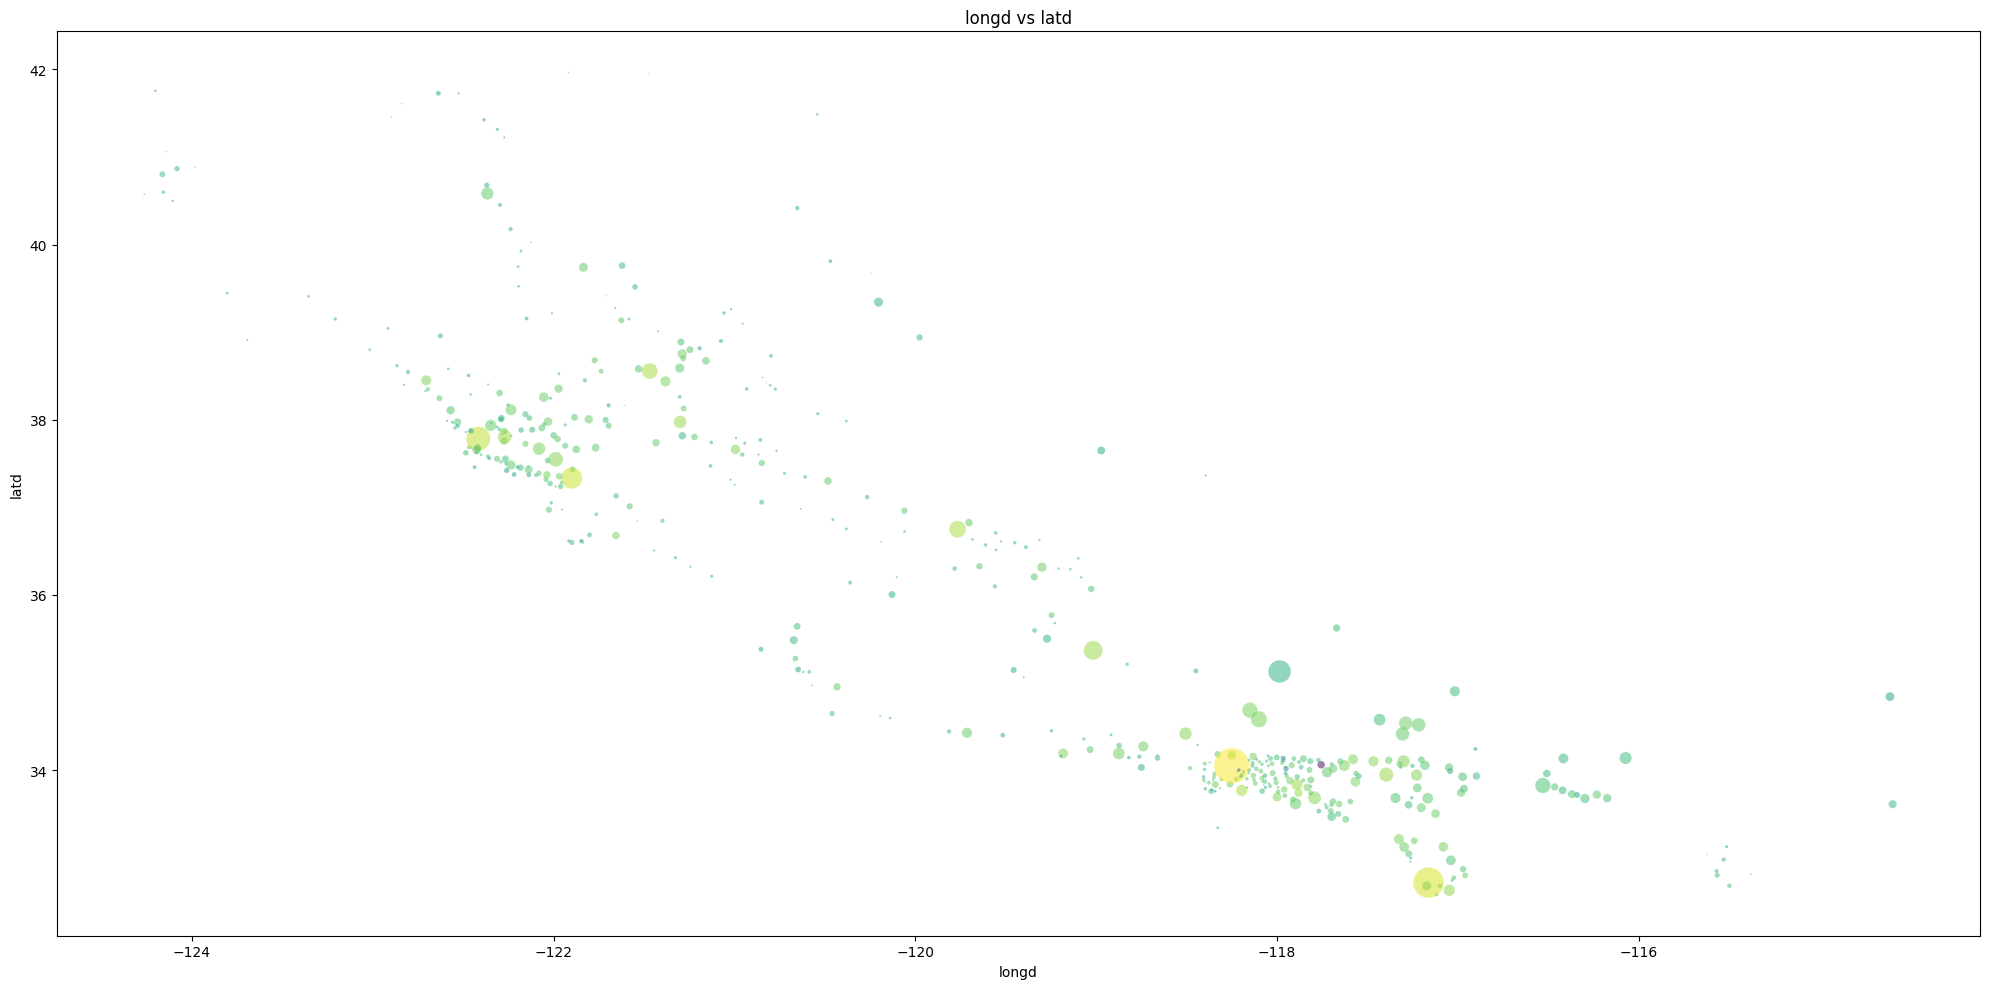

In [250]:
#1.3

scatter_with_controls(df, 'longd', 'latd', 'log_poblacion', 'area_total_km2', 0.5, True)

## #2: Presentación

En esta parte tendrás que hacer dos cosas, crear una presentación sobre el titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  
1- El titanic fue un accidente con una tasa de mortalidad alta.  
2- En esa ocasión los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3- ... que la clase en la que se viajes tuvo una influencia significativa y podría explicar...  
4- ... las diferencias de tasas de supervivencia entre mujeres y niños.    
5- Además aunque el puerto de embarque parece influir, se podría asumir que lo fue el tipo de pasaje que embarcó en cada uno.  

Y generar el notebook con las gráficas que vas a emplear en la presentación. Tienes que entregar ambas cosas.

In [251]:
df = pd.read_csv('../../Sprint 7 - Análisis explicativo y descriptivo/Unidad 2 - Análisis Multivariante/data/titanic.csv')

In [252]:
df = sns.load_dataset('titanic')

In [253]:
#### colores = ['#FF7F7F', '#87CEEB']                
#### para suavizar los colores y que sea más agradable a la visata

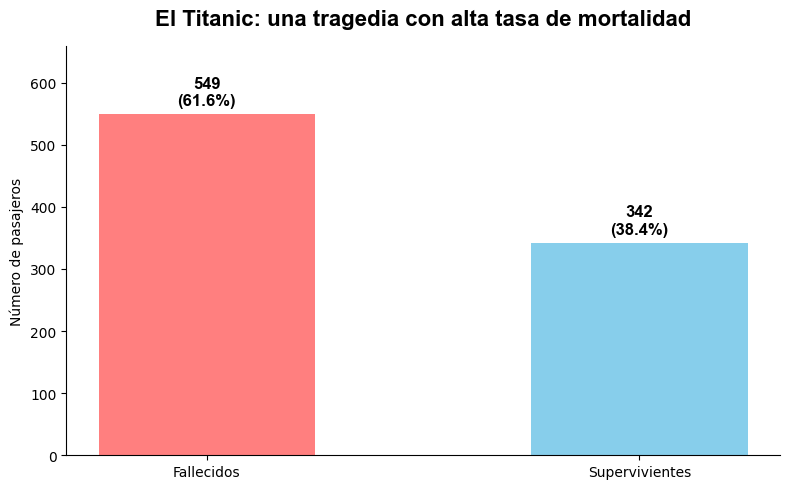

In [254]:
### 1. Tasa de mortalidad alta

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 5))

categorias = ['Fallecidos', 'Supervivientes']
valores = [df['survived'].value_counts()[0], df['survived'].value_counts()[1]]
colores = ['#FF7F7F', '#87CEEB']

bars = ax.bar(categorias, valores, color=colores, width=0.5)


#tags

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val}\n({val/sum(valores)*100:.1f}%)',
            ha='center', va='bottom', fontname= 'Arial', fontsize=12, fontweight='bold')

ax.set_title('El Titanic: una tragedia con alta tasa de mortalidad', fontname= 'Arial', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Número de pasajeros')
ax.set_ylim(0, max(valores) * 1.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

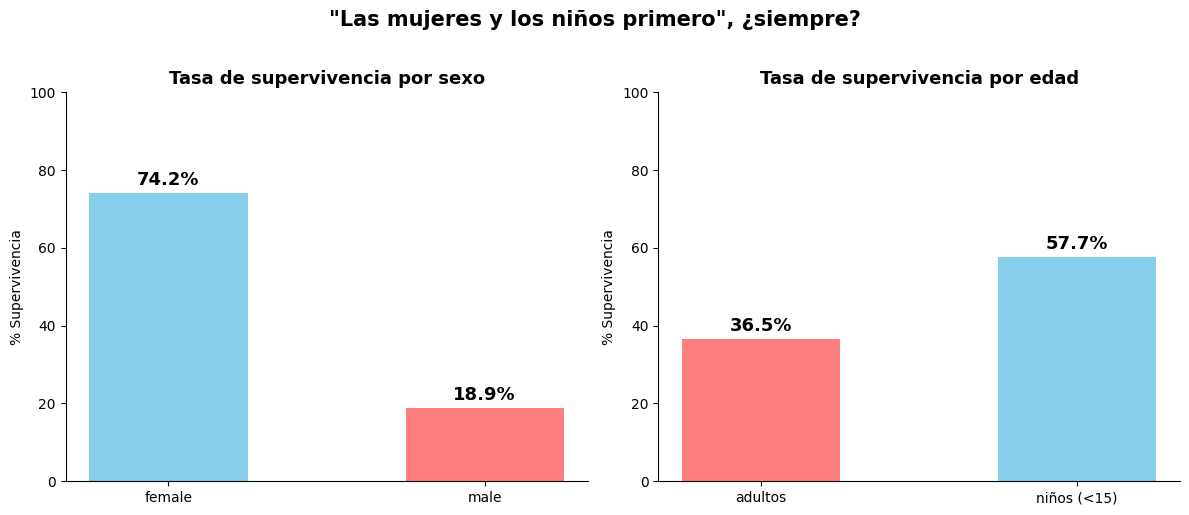

In [255]:
## 2. Las mujeres y los niños primeros, pero...

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#### A LA IZQUIERDA, PRIMER GRÁFICO: SUPERVIVENCIA X SEXO

supervivencia_sexo = df.groupby('sex')['survived'].mean() * 100

axes[0].bar(supervivencia_sexo.index, supervivencia_sexo.values,
            color=['#87CEEB', '#FF7F7F'], width=0.5)                                        #colores menos chocantes

for i, (idx, val) in enumerate(supervivencia_sexo.items()):
    axes[0].text(i, val + 1, f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=13, fontweight='bold')

axes[0].set_title('Tasa de supervivencia por sexo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% Supervivencia')
axes[0].set_ylim(0, 100)
axes[0].spines[['top', 'right']].set_visible(False)

#### A LA DERECHA, SEGUNDO GRÁFICO: SUPERVIVENCIA X EDAD

df['es_nino'] = df['age'] < 15
supervivencia_edad = df.groupby('es_nino')['survived'].mean() * 100

axes[1].bar(['adultos', 'niños (<15)'], supervivencia_edad.values,
            color=['#FF7F7F', '#87CEEB'], width=0.5)

for i, val in enumerate(supervivencia_edad.values):
    axes[1].text(i, val + 1, f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=13, fontweight='bold')

axes[1].set_title('Tasa de supervivencia por edad', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% Supervivencia')
axes[1].set_ylim(0, 100)
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('"Las mujeres y los niños primero", ¿siempre?', 
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

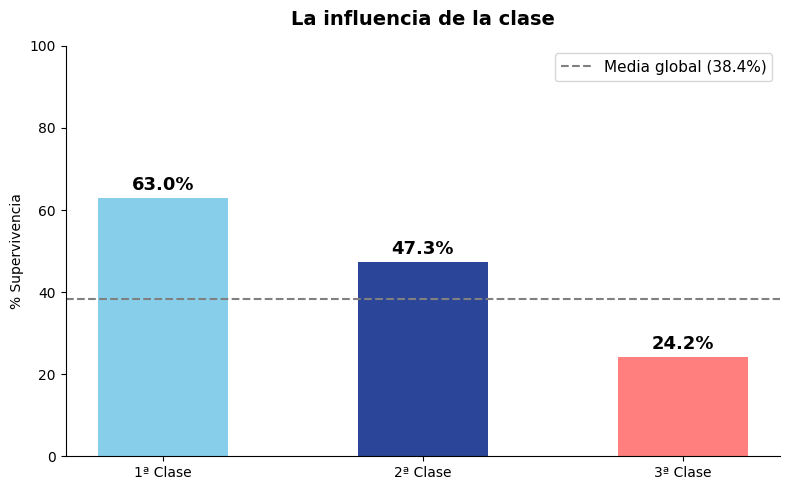

In [256]:
# 3. La clase

fig, ax = plt.subplots(figsize=(8, 5))

supervivencia_clase = df.groupby('pclass')['survived'].mean() * 100

colores = ['#87CEEB', '#2B4699', '#FF7F7F']
bars = ax.bar(['1ª Clase', '2ª Clase', '3ª Clase'], 
              supervivencia_clase.values,
              color=colores, width=0.5)

for bar, val in zip(bars, supervivencia_clase.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold')


tasa_global = df['survived'].mean() * 100
ax.axhline(y=tasa_global, color='gray', linestyle='--', linewidth=1.5, label=f'Media global ({tasa_global:.1f}%)')

ax.set_title('La influencia de la clase', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('% Supervivencia')
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

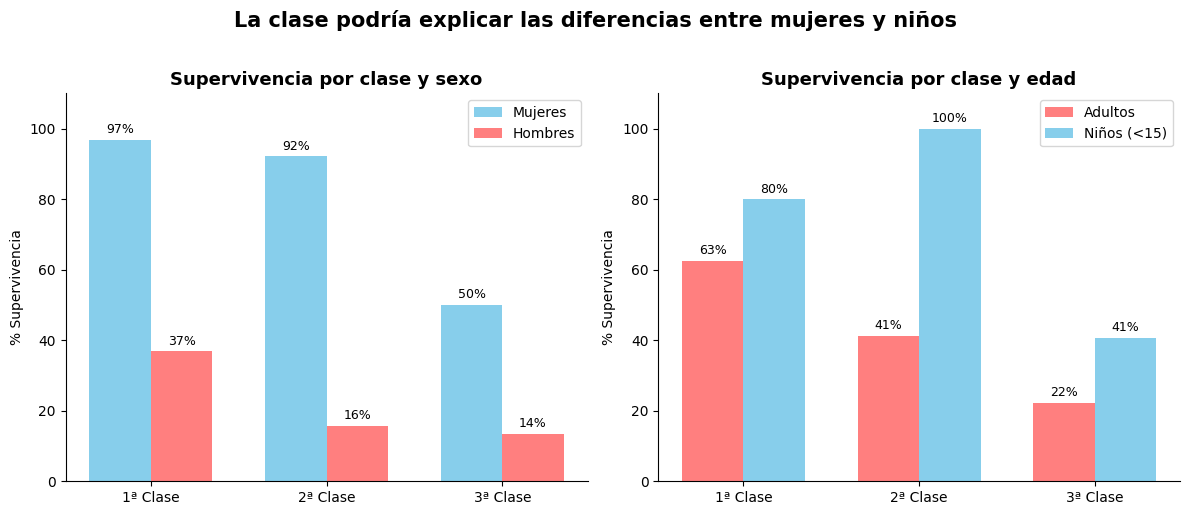

In [257]:
# 4. La clase y la edad

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#### A LA IZQUIERDA, PRIMER GRÁFICO: SUPERVIVENCIA X SEXO
supervivencia_clase_sexo = df.groupby(['pclass', 'sex'])['survived'].mean() * 100
supervivencia_clase_sexo = supervivencia_clase_sexo.unstack()

x = [0, 1, 2]
width = 0.35
clases = ['1ª Clase', '2ª Clase', '3ª Clase']

bars1 = axes[0].bar([i - width/2 for i in x], supervivencia_clase_sexo['female'].values,
                     width=width, color='#87CEEB', label='Mujeres')
bars2 = axes[0].bar([i + width/2 for i in x], supervivencia_clase_sexo['male'].values,
                     width=width, color='#FF7F7F', label='Hombres')

for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(clases)
axes[0].set_title('Supervivencia por clase y sexo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% Supervivencia')
axes[0].set_ylim(0, 110)
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

#### A LA DERECHA, SEGUNDO GRÁFICO: EDAD Y SUPERVIVENCIA
supervivencia_clase_edad = df.groupby(['pclass', 'es_nino'])['survived'].mean() * 100
supervivencia_clase_edad = supervivencia_clase_edad.unstack()

bars3 = axes[1].bar([i - width/2 for i in x], supervivencia_clase_edad[False].values,
                     width=width, color='#FF7F7F', label='Adultos')
bars4 = axes[1].bar([i + width/2 for i in x], supervivencia_clase_edad[True].values,
                     width=width, color='#87CEEB', label='Niños (<15)')

for bar in list(bars3) + list(bars4):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(clases)
axes[1].set_title('Supervivencia por clase y edad', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% Supervivencia')
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('La clase podría explicar las diferencias entre mujeres y niños',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

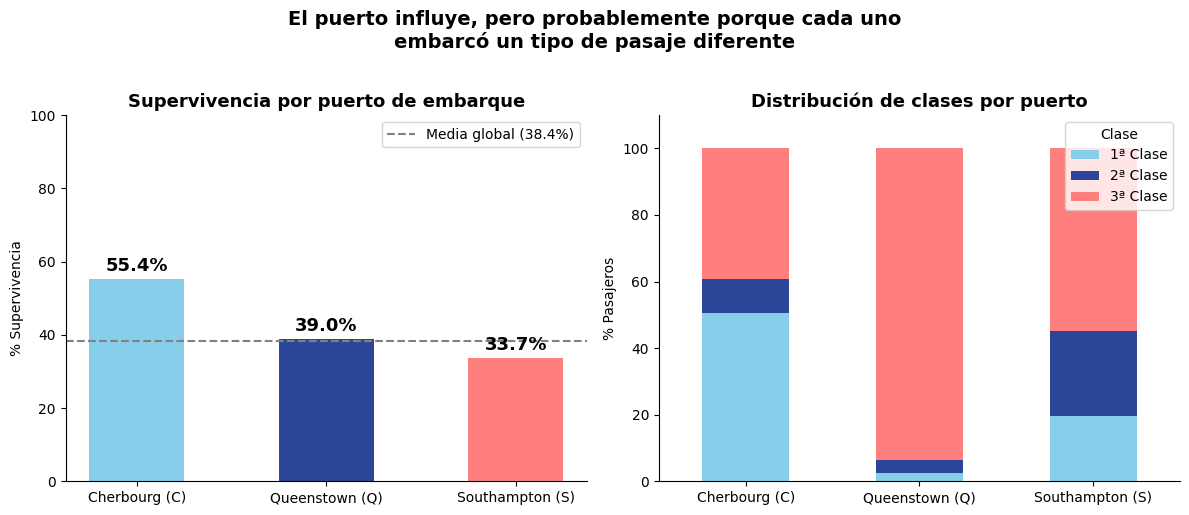

In [258]:
# 5. Sobre el puerto de embarque y el tipo de pasaje

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#### A LA IZQUIERDA, PRIMER GRÁFICO: SUPERVIVENCIA X PUERTO DE EMBARQUE

supervivencia_puerto = df.groupby('embarked')['survived'].mean() * 100

axes[0].bar(['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'],
            supervivencia_puerto.values,
            color=['#87CEEB', '#2B4699', '#FF7F7F'], width=0.5)

for i, val in enumerate(supervivencia_puerto.values):
    axes[0].text(i, val + 1, f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=13, fontweight='bold')

tasa_global = df['survived'].mean() * 100
axes[0].axhline(y=tasa_global, color='gray', linestyle='--', linewidth=1.5,
                label=f'Media global ({tasa_global:.1f}%)')

axes[0].set_title('Supervivencia por puerto de embarque', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% Supervivencia')
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

#### A LA DERECHA, SEGUNDO  GRÁFICO: CLASES X PUERTO
clase_puerto = df.groupby(['embarked', 'pclass']).size().unstack()
clase_puerto_pct = clase_puerto.div(clase_puerto.sum(axis=1), axis=0) * 100

clase_puerto_pct.index = ['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)']

clase_puerto_pct.plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['#87CEEB', '#2B4699', '#FF7F7F'],
    width=0.5
)

axes[1].set_title('Distribución de clases por puerto', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% Pasajeros')
axes[1].set_ylim(0, 110)
axes[1].set_xticklabels(['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'], rotation=0)
axes[1].legend(title='Clase', labels=['1ª Clase', '2ª Clase', '3ª Clase'])
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('El puerto influye, pero probablemente porque cada uno\nembarcó un tipo de pasaje diferente',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

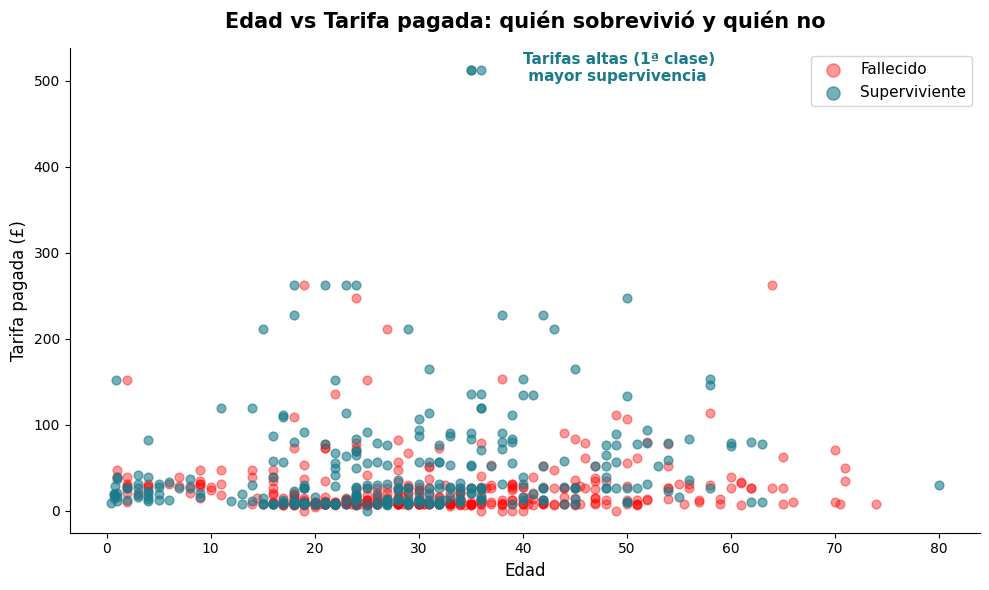

In [259]:
##### RESUMEN 


fig, ax = plt.subplots(figsize=(10, 6))

fallecidos = df[df['survived'] == 0]
supervivientes = df[df['survived'] == 1]

ax.scatter(fallecidos['age'], fallecidos['fare'], 
           color='red', alpha=0.4, s=40, label='Fallecido')
ax.scatter(supervivientes['age'], supervivientes['fare'], 
           color='#1A7A8A', alpha=0.6, s=40, label='Superviviente')

ax.set_title('Edad vs Tarifa pagada: quién sobrevivió y quién no',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Edad', fontsize=12)
ax.set_ylabel('Tarifa pagada (£)', fontsize=12)
ax.legend(fontsize=11, title='', markerscale=1.5)
ax.spines[['top', 'right']].set_visible(False)

# Outliner
ax.annotate('Tarifas altas (1ª clase)\n mayor supervivencia',
            xy=(40, 500), fontsize=11, color='#1A7A8A',
            fontweight='bold')

plt.tight_layout()
plt.show()